#### Import all the reuired libraries

In [ ]:
import sqlite3
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gzip
from tqdm.notebook import tqdm
import gc

plt.style.use("ggplot")

In [2]:
# Connect to database
conn = sqlite3.connect("mimic.db")
conn.execute("PRAGMA foreign_keys = ON;")

# Confirm connection
pd.read_sql("PRAGMA database_list;", conn)

,seq,name,file
0,0,main,/blue/cap5771/shesadree.p/CAP5771_lili1501/mim...


In [3]:
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "mimic dataset"

# PROBLEM FORMULATION

**Problem Statement**

The objective of this project is to develop a predictive model to estimate the probability of ICU mortality using patient data collected within the first 72 hours of ICU admission.

This is a supervised binary classification problem.

**Inputs**

Patient-level features aggregated from the first 72 hours of ICU stay:
- Demographics: age, gender, race, ICU type
- Vital signs: mean heart rate, mean MAP, mean respiratory rate, mean SpO₂, mean SBP, mean DBP
- Laboratory markers: max lactate, max creatinine, max bilirubin, max BUN, max WBC, min platelets,mean sodium, mean potassium
- Urine output: total urine output over 72 hours

All features are derived strictly from data recorded between ICU admission time and +72 hours.

**Output**

Binary outcome: hospital_expire_flag

- 0 → Survived ICU stay
- 1 → Died during hospital stay

**Time Horizon**

- Prediction window: First 72 hours of ICU admission
- Outcome: Mortality during the same hospitalization

This ensures no future information beyond the 72-hour window is used for prediction (avoids data leakage).

**Measurable Objective**

Model performance will be evaluated using:

- Area Under ROC Curve (AUROC)
- Precision-Recall metrics
- Calibration performance

# DATA ACQUISITION (PART-1)

**Data Source**

- Dataset: MIMIC-IV (Medical Information Mart for Intensive Care)
- Accessed via PhysioNet (credentialed access required, CITI Training and Physionet account)
- Data provided as structured CSV files

**Data Collection Process**

1. Download required CSV files from PhysioNet.

2. Create local SQLite database (mimic_iv.db).

3. Load raw tables:

   - patients
   - admissions
   - icustays
   - chartevents
   - labevents
   - outputevents
   - d_items
   - d_labitems

4. Create 72-hour filtered views:
   - chartevents_72h
   - labevents_72h
   - outputevents_72h

5. Aggregate features using SQL GROUP BY.

6. Merge into final dataset: icu_features (As shown in Data acquisition database management)

All steps are reproducible through SQL scripts and Python preprocessing

**Reproducibility**

_Note: Due to PhysioNet licensing restrictions, the `.db` file is not included in this repository._

Database schema included in repository.
- Refer db_instruction.md to create the db

Feature engineering queries documented.

The pre final dataset with required featured generated programmatically. (as there are thousands of variables present so choose the required one based on the problem statement)

No manual data manipulation.

### DATA DICTIONARY

**Relational / Join Variables (Not Modeling Features)**

These variables are used for linking tables and constructing the final dataset but are not used directly as predictive features.


**Patient-Level Identifiers**

| Variable | Description | Source | Role |
|----------|------------|--------|------|
| subject_id | Unique patient identifier | patients | Links patient across hospital admissions and ICU stays |


**Hospital Admission Identifiers**

| Variable | Description | Source | Role |
|----------|------------|--------|------|
| hadm_id | Unique hospital admission identifier | admissions | Links hospital-level data to ICU stays and labs |


**ICU Stay Identifier**

| Variable | Description | Source | Role |
|----------|------------|--------|------|
| stay_id | Unique ICU stay identifier | icustays | Primary unit of analysis (one row per ICU stay) |

**Measurement Identifiers**

| Variable | Description | Source | Role |
|----------|------------|--------|------|
| itemid | Unique measurement code | chartevents / labevents / outputevents | Identifies specific lab or vital measurement |
| charttime | Timestamp of measurement | chartevents / labevents | Used for 72-hour filtering |
| valuenum | Numeric measurement value | chartevents / labevents | Used for aggregation |
| value | Measurement value (may be non-numeric) | chartevents | Raw value field |

**Purpose in Data Pipeline**

These identifiers were used to:

- Join `patients`, `admissions`, and `icustays`
- Filter measurements to the first 72 hours
- Aggregate time-series data using `GROUP BY stay_id`
- Construct derived feature tables (`vital_features_72h`, `lab_features_72h`, etc.)


_Clarification_

- `subject_id`, `hadm_id`, and `itemid` are **not used as predictive features**.
- They are structural identifiers required for relational database operations.
- Only aggregated clinical variables are included in the final modeling table.


Relational identifiers ensure correct linkage across tables but are excluded from modeling to avoid leakage and meaningless numerical encoding (future after milestone 1)


**Table used for EDA**

This table contains one row per ICU stay (`stay_id`) and includes features derived from the first 72 hours of ICU admission.


**Identifier**

| Variable | Description | Source |
|----------|------------|--------|
| stay_id | Unique ICU stay identifier | icustays |


**Demographics**

| Variable | Description | Unit | Source |
|----------|------------|------|--------|
| age | Patient age at ICU admission | Years | patients |
| gender | Biological sex of patient | Categorical | patients |
| race | Self-reported race | Categorical | admissions |
| admission_location | Location prior to hospital admission | Categorical | admissions |
| first_careunit | First ICU unit admitted to | Categorical | icustays |
| los | ICU length of stay | Days | icustays |
| hospital_expire_flag | In-hospital mortality indicator (0=survived, 1=died) | Binary | admissions |


**Vital Signs (First 72 Hours)**

All vital signs are aggregated from `chartevents` within 72 hours of ICU admission.

| Variable | Description | Unit | Aggregation |
|----------|------------|------|-------------|
| mean_hr | Mean heart rate | bpm | Average |
| min_hr | Minimum heart rate | bpm | Minimum |
| max_hr | Maximum heart rate | bpm | Maximum |
| mean_map | Mean mean arterial pressure | mmHg | Average |
| min_map | Minimum MAP | mmHg | Minimum |
| max_map | Maximum MAP | mmHg | Maximum |
| mean_sbp | Mean systolic BP | mmHg | Average |
| min_sbp | Minimum systolic BP | mmHg | Minimum |
| max_sbp | Maximum systolic BP | mmHg | Maximum |
| mean_dbp | Mean diastolic BP | mmHg | Average |
| min_dbp | Minimum diastolic BP | mmHg | Minimum |
| max_dbp | Maximum diastolic BP | mmHg | Maximum |
| mean_rr | Mean respiratory rate | breaths/min | Average |
| min_rr | Minimum respiratory rate | breaths/min | Minimum |
| max_rr | Maximum respiratory rate | breaths/min | Maximum |
| mean_spo2 | Mean oxygen saturation | % | Average |
| min_spo2 | Minimum oxygen saturation | % | Minimum |
| max_spo2 | Maximum oxygen saturation | % | Maximum |
| mean_temp_c | Mean body temperature | °C | Average (converted to Celsius) |
| max_fio2 | Maximum fraction of inspired oxygen | Fraction (0–1) | Maximum (normalized) |
| max_pao2 | Maximum arterial oxygen pressure | mmHg | Maximum |



**Laboratory Features (First 72 Hours)**

Aggregated from `labevents` within 72 hours.

| Variable | Description | Unit | Aggregation |
|----------|------------|------|-------------|
| max_creatinine | Maximum serum creatinine | mg/dL | Maximum |
| min_creatinine | Minimum serum creatinine | mg/dL | Minimum |
| mean_creatinine | Mean serum creatinine | mg/dL | Average |
| max_lactate | Maximum serum lactate | mmol/L | Maximum |
| min_lactate | Minimum lactate | mmol/L | Minimum |
| mean_lactate | Mean lactate | mmol/L | Average |
| max_bilirubin | Maximum total bilirubin | mg/dL | Maximum |
| min_bilirubin | Minimum bilirubin | mg/dL | Minimum |
| mean_bilirubin | Mean bilirubin | mg/dL | Average |
| max_wbc | Maximum white blood cell count | K/uL | Maximum |
| min_wbc | Minimum WBC | K/uL | Minimum |
| mean_wbc | Mean WBC | K/uL | Average |
| max_hemog | Maximum hemoglobin | g/dL | Maximum |
| min_hemog | Minimum hemoglobin | g/dL | Minimum |
| mean_hemog | Mean hemoglobin | g/dL | Average |
| max_sodium | Maximum sodium | mmol/L | Maximum |
| min_sodium | Minimum sodium | mmol/L | Minimum |
| mean_sodium | Mean sodium | mmol/L | Average |
| max_potassium | Maximum potassium | mmol/L | Maximum |
| min_potassium | Minimum potassium | mmol/L | Minimum |
| mean_potassium | Mean potassium | mmol/L | Average |
| max_bun | Maximum blood urea nitrogen | mg/dL | Maximum |
| min_bun | Minimum BUN | mg/dL | Minimum |
| mean_bun | Mean BUN | mg/dL | Average |
| max_platelets | Maximum platelet count | K/uL | Maximum |
| min_platelets | Minimum platelet count | K/uL | Minimum |
| mean_platelets | Mean platelet count | K/uL | Average |



**Outputevents**

| Variable | Description | Unit | Aggregation | Source |
|----------|------------|------|-------------|--------|
| total_urine_72h | Total urine output in first 72 hours | mL | Sum | outputevents |



**Notes**

- All time-dependent features are restricted to the first 72 hours after ICU admission.
- Summary statistics (mean, min, max) were computed using SQL `GROUP BY stay_id`.
- Temperature values were standardized to Celsius.
- FiO2 values were normalized to fractional scale (0–1).
- One row represents one ICU stay.


# DATA ACQUISITION (DATABASE MANAGEMENT)

In [ ]:
#
# conn.executescript("""
# DROP TABLE IF EXISTS icustays;
# DROP TABLE IF EXISTS inputevents;
# DROP TABLE IF EXISTS outputevents;
# DROP TABLE IF EXISTS chartevents;
# DROP TABLE IF EXISTS labevents;
# DROP TABLE IF EXISTS diagnoses_icd;
# DROP TABLE IF EXISTS admissions;
# DROP TABLE IF EXISTS patients;
# DROP TABLE IF EXISTS d_icd_diagnoses;
# DROP TABLE IF EXISTS d_icd_procedures;
# DROP TABLE IF EXISTS d_labitems;
# DROP TABLE IF EXISTS d_items;
# """)

#### Schema Hospital

In [ ]:
schema = """
CREATE TABLE patients (
    subject_id INTEGER PRIMARY KEY,
    gender TEXT,
    anchor_age INTEGER,
    anchor_year INTEGER,
    anchor_year_group TEXT,
    dod TEXT
);

CREATE TABLE admissions (
    hadm_id INTEGER PRIMARY KEY,
    subject_id INTEGER,
    admittime TEXT,
    dischtime TEXT,
    deathtime TEXT,
    admission_type TEXT,
    admit_provider_id TEXT,
    admission_location TEXT,
    discharge_location TEXT,
    insurance TEXT,
    language TEXT,
    marital_status TEXT,
    race TEXT,
    edregtime TEXT,
    edouttime TEXT,
    hospital_expire_flag INTEGER,
    FOREIGN KEY (subject_id) REFERENCES patients(subject_id)
);

CREATE TABLE diagnoses_icd (
    subject_id INTEGER,
    hadm_id INTEGER,
    seq_num INTEGER,
    icd_code TEXT,
    icd_version INTEGER,
    FOREIGN KEY (subject_id) REFERENCES patients(subject_id),
    FOREIGN KEY (hadm_id) REFERENCES admissions(hadm_id)
);



CREATE TABLE labevents (
    labevent_id INTEGER NOT NULL,
    subject_id INTEGER NOT NULL,
    hadm_id INTEGER,
    specimen_id INTEGER NOT NULL,
    itemid INTEGER NOT NULL,
    order_provider_id TEXT,
    charttime TEXT,
    storetime TEXT,
    value TEXT,
    valuenum REAL,
    valueuom TEXT,
    ref_range_lower REAL,
    ref_range_upper REAL,
    flag TEXT,
    priority TEXT,
    comments TEXT,
    FOREIGN KEY (subject_id) REFERENCES patients(subject_id),
    FOREIGN KEY (hadm_id) REFERENCES admissions(hadm_id)
);
"""
conn.executescript(schema)


### Mapping Schema

In [ ]:
#optional : d_icd_diagnoses, d_icd_procedures

schema = """

CREATE TABLE d_icd_diagnoses (
    icd_code TEXT NOT NULL,
    icd_version INTEGER NOT NULL,
    long_title TEXT,
    PRIMARY KEY (icd_code, icd_version)
);


CREATE TABLE d_icd_procedures (
    icd_code TEXT NOT NULL,
    icd_version INTEGER NOT NULL,
    long_title TEXT,
    PRIMARY KEY (icd_code, icd_version)
);


CREATE TABLE d_labitems (
    itemid INTEGER PRIMARY KEY,
    label TEXT,
    fluid TEXT,
    category TEXT
);


CREATE TABLE d_items (
    itemid INTEGER PRIMARY KEY,
    label TEXT,
    abbreviation TEXT,
    linksto TEXT,
    category TEXT,
    unitname TEXT,
    param_type TEXT,
    lownormalvalue REAL,
    highnormalvalue REAL
);

"""
conn.executescript(schema)


### ICU Schema

In [ ]:
schema = """

CREATE TABLE icustays (
    subject_id INTEGER NOT NULL,
    hadm_id INTEGER,
    stay_id INTEGER NOT NULL,
    first_careunit TEXT,
    last_careunit TEXT,
    intime TEXT,
    outtime TEXT,
    los REAL,
    PRIMARY KEY (stay_id)
);


CREATE TABLE inputevents (
    subject_id INTEGER NOT NULL,
    hadm_id INTEGER,
    stay_id INTEGER,
    caregiver_id INTEGER,
    starttime TEXT,
    endtime TEXT,
    storetime TEXT,
    itemid INTEGER,
    amount REAL,
    amountuom TEXT,
    rate REAL,
    rateuom TEXT,
    orderid INTEGER,
    linkorderid INTEGER,
    ordercategoryname TEXT,
    secondaryordercategoryname TEXT,
    ordercomponenttypedescription TEXT,
    ordercategorydescription TEXT,
    patientweight REAL,
    totalamount REAL,
    totalamountuom TEXT,
    isopenbag INTEGER,
    continueinnextdept INTEGER,
    statusdescription TEXT,
    originalamount REAL,
    originalrate REAL
);


CREATE TABLE outputevents (
    subject_id INTEGER NOT NULL,
    hadm_id INTEGER,
    stay_id INTEGER,
    caregiver_id INTEGER,
    charttime TEXT,
    storetime TEXT,
    itemid INTEGER,
    value REAL,
    valueuom TEXT
);



CREATE TABLE chartevents (
    subject_id INTEGER NOT NULL,
    hadm_id INTEGER,
    stay_id INTEGER,
    caregiver_id INTEGER,
    charttime TEXT,
    storetime TEXT,
    itemid INTEGER,
    value TEXT,
    valuenum REAL,
    valueuom TEXT,
    warning INTEGER
);


"""
conn.executescript(schema)


#### Create connection with mimic.db

In [ ]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';",conn)

#### Load the compressed csv file with this helper function that handles small and large files(loaded in chunk size to avoid memory/kernel crash )

In [ ]:
def load_csv_gz(path,table,subject_set=None,chunksize=None):
    
    print(f"Loading {path.name} → {table}")

    if chunksize:
        for chunk in tqdm(
            pd.read_csv(path, compression="gzip", chunksize=chunksize),
            desc=table
        ):
            # Filter by sampled subjects if provided
            if subject_set is not None and "subject_id" in chunk.columns:
                chunk = chunk[chunk["subject_id"].isin(subject_set)]

            if not chunk.empty:
                chunk.to_sql(table, conn, if_exists="append", index=False)

            del chunk
            gc.collect()
    else:
        df = pd.read_csv(path, compression="gzip")

        if subject_set is not None and "subject_id" in df.columns:
            df = df[df["subject_id"].isin(subject_set)]

        if not df.empty:
            df.to_sql(table, conn, if_exists="append", index=False)



#### Safechecks to avoid out of memory warning/ crash

In [ ]:
conn.execute("PRAGMA journal_mode = OFF;")
conn.execute("PRAGMA synchronous = OFF;")
conn.execute("PRAGMA temp_store = MEMORY;")

#### Using 10% of patients for intial EDA due to large file

In [ ]:
load_csv_gz(DATA_DIR / "hosp/patients.csv.gz", "patients")

sampled_subjects = pd.read_sql("""
SELECT subject_id
FROM patients
ORDER BY RANDOM()
LIMIT (
    SELECT CAST(COUNT(DISTINCT subject_id) * 0.10 AS INT)
    FROM patients
);
""", conn)

print(f"Sampled {len(sampled_subjects)} subjects.")
sampled_subjects.head()

In [ ]:
subject_set = set(sampled_subjects["subject_id"])

In [ ]:
#hospital tables
load_csv_gz(DATA_DIR / "hosp/admissions.csv.gz", "admissions", subject_set=subject_set)
load_csv_gz(DATA_DIR / "hosp/diagnoses_icd.csv.gz", "diagnoses_icd", subject_set=subject_set)
load_csv_gz(DATA_DIR / "hosp/d_icd_diagnoses.csv.gz", "d_icd_diagnoses")
load_csv_gz(DATA_DIR / "hosp/d_icd_procedures.csv.gz", "d_icd_procedures")
load_csv_gz(DATA_DIR / "hosp/d_labitems.csv.gz", "d_labitems")

#icu tables
load_csv_gz(DATA_DIR / "icu/d_items.csv.gz", "d_items")
load_csv_gz(DATA_DIR / "icu/icustays.csv.gz", "icustays", subject_set=subject_set)

In [ ]:
load_csv_gz(DATA_DIR / "hosp/labevents.csv.gz","labevents", subject_set=subject_set, chunksize=50_000)
load_csv_gz(DATA_DIR / "icu/inputevents.csv.gz", "inputevents", subject_set=subject_set, chunksize=50_000)
load_csv_gz(DATA_DIR / "icu/outputevents.csv.gz", "outputevents", subject_set=subject_set, chunksize=50_000)
load_csv_gz(DATA_DIR / "icu/chartevents.csv.gz", "chartevents", subject_set=subject_set, chunksize=50_000)

#### Creating intermediate view tables

In [ ]:
conn.executescript("""
DROP VIEW IF EXISTS chartevents_72h;

CREATE VIEW chartevents_72h AS
SELECT c.*
FROM chartevents c
JOIN icustays s USING (stay_id)
WHERE datetime(c.charttime) >= datetime(s.intime)
  AND datetime(c.charttime) <= datetime(s.intime, '+72 hours');
""")


In [ ]:
conn.executescript("""
DROP VIEW IF EXISTS labevents_72h;

CREATE VIEW labevents_72h AS
SELECT l.*, s.stay_id
FROM labevents l
JOIN icustays s
  ON l.subject_id = s.subject_id
 AND l.hadm_id = s.hadm_id
WHERE datetime(l.charttime) >= datetime(s.intime)
  AND datetime(l.charttime) <= datetime(s.intime, '+72 hours');
""")

In [ ]:
conn.executescript("""
DROP VIEW IF EXISTS outputevents_72h;

CREATE VIEW outputevents_72h AS
SELECT o.*
FROM outputevents o
JOIN icustays s USING (stay_id)
WHERE datetime(o.charttime) >= datetime(s.intime)
  AND datetime(o.charttime) <= datetime(s.intime, '+72 hours');
""")


#### Only keeping required itemids from chartevents and labevents 

##### Required itemids from chart

In [ ]:
# heartrate itemids
hr_ids = pd.read_sql("""
SELECT d.itemid
FROM chartevents c
JOIN d_items d USING (itemid)
WHERE LOWER(d.label) IN ('heart rate')
GROUP BY d.itemid
""", conn)["itemid"].tolist()

print(hr_ids)

In [ ]:
# blood pressure itemids

map_ids = pd.read_sql("""
SELECT d.itemid
FROM chartevents c
JOIN d_items d USING (itemid)
WHERE LOWER(d.label) IN ('arterial blood pressure mean','non invasive blood pressure mean')
GROUP BY d.itemid
""", conn)["itemid"].tolist()

print(map_ids)

In [ ]:
# respiratory rate itemids

rr_ids = pd.read_sql("""
SELECT d.itemid
FROM chartevents c
JOIN d_items d USING (itemid)
WHERE LOWER(d.label) IN (
    'respiratory rate',
    'respiratory rate (spontaneous)',
    'respiratory rate (total)'
)
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(rr_ids)

In [ ]:
# arterial blood pressure systolic and diastolic itemids

sbp_ids = pd.read_sql("""
SELECT d.itemid
FROM chartevents c
JOIN d_items d USING (itemid)
WHERE LOWER(d.label) IN ('arterial blood pressure systolic','non invasive blood pressure systolic')
GROUP BY d.itemid
""", conn)["itemid"].tolist()

print(sbp_ids)

dbp_ids = pd.read_sql("""
SELECT d.itemid
FROM chartevents c
JOIN d_items d USING (itemid)
WHERE LOWER(d.label) IN ('arterial blood pressure diastolic','non invasive blood pressure diastolic')
GROUP BY d.itemid
""", conn)["itemid"].tolist()

print(dbp_ids)

In [ ]:
# oxygen saturation itemids
spo2_ids = pd.read_sql("""
SELECT d.itemid
FROM chartevents c
JOIN d_items d USING (itemid)
WHERE LOWER(d.label) = 'o2 saturation pulseoxymetry'
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(spo2_ids)

In [ ]:
# inspired oxygen fraction itemids

fio2_ids = pd.read_sql("""
SELECT d.itemid
FROM chartevents c
JOIN d_items d USING (itemid)
WHERE LOWER(d.label) = 'inspired o2 fraction'
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(fio2_ids)

In [ ]:
#arterial oxygen pressure itemids

pao2_ids = pd.read_sql("""
SELECT d.itemid
FROM chartevents c
JOIN d_items d USING (itemid)
WHERE LOWER(d.label) = 'arterial o2 pressure'
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(pao2_ids)

In [ ]:
# body temperature itemids

temp_ids = pd.read_sql("""
SELECT d.itemid
FROM chartevents c
JOIN d_items d USING (itemid)
WHERE LOWER(d.label) IN (
    'temperature fahrenheit',
    'temperature celsius'
)
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(temp_ids)

### Required itemids from lab

In [ ]:
#creatinine itemids 

creatinine_ids = pd.read_sql("""
SELECT d.itemid
FROM labevents l
JOIN d_labitems d USING (itemid)
WHERE LOWER(d.label) IN ('creatinine')
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(creatinine_ids)

In [ ]:
# lactate itemids

lactate_ids = pd.read_sql("""
SELECT d.itemid
FROM labevents l
JOIN d_labitems d USING (itemid)
WHERE LOWER(d.label) = 'lactate'
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(lactate_ids)

In [ ]:
#bilirubin itemids

bilirubin_ids = pd.read_sql("""
SELECT d.itemid
FROM labevents l
JOIN d_labitems d USING (itemid)
WHERE LOWER(d.label) = 'bilirubin, total'
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(bilirubin_ids)

In [ ]:
# white blood cell count itemids

wbc_ids = pd.read_sql("""
SELECT d.itemid
FROM labevents l
JOIN d_labitems d USING (itemid)
WHERE LOWER(d.label) IN ('wbc', 'wbc count','white blood cells')
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(wbc_ids)

In [ ]:
# platelet count itemids

platelet_ids = pd.read_sql("""
SELECT d.itemid
FROM labevents l
JOIN d_labitems d USING (itemid)
WHERE LOWER(d.label) = 'platelet count'
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(platelet_ids)

In [ ]:
# hemoglobin, sodium, potassium and blood urea nitrogen itemids

hemog_ids = pd.read_sql("""
SELECT d.itemid
FROM labevents l
JOIN d_labitems d USING (itemid)
WHERE LOWER(d.label) IN( 'hemoglobin', 'absolute hemoglobin','hemoglobin, calculated')
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(hemog_ids)

sodium_ids = pd.read_sql("""
SELECT d.itemid
FROM labevents l
JOIN d_labitems d USING (itemid)
WHERE LOWER(d.label) IN ('sodium', 'sodium, whole blood')
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(sodium_ids)

potassium_ids = pd.read_sql("""
SELECT d.itemid
FROM labevents l
JOIN d_labitems d USING (itemid)
WHERE LOWER(d.label) IN ('potassium', 'potassium, whole blood')
GROUP BY d.itemid;
""", conn)["itemid"].tolist()

print(potassium_ids)

bun_ids = 51842

#### Taking the MAX, MIN AND MEAN of vitals from chartevents_72h (intermediate table)

In [ ]:
conn.execute("BEGIN;")
conn.executescript(f"""
DROP TABLE IF EXISTS vital_features_72h;

CREATE TABLE vital_features_72h AS
SELECT
    stay_id,

    MAX(CASE WHEN itemid IN ({','.join(map(str, hr_ids))}) THEN valuenum END) AS max_hr,
    MIN(CASE WHEN itemid IN ({','.join(map(str, hr_ids))}) THEN valuenum END) AS min_hr,
    AVG(CASE WHEN itemid IN ({','.join(map(str, hr_ids))}) THEN valuenum END) AS mean_hr,
    
    MAX(CASE WHEN itemid IN ({','.join(map(str, map_ids))}) THEN valuenum END) AS max_map,
    MIN(CASE WHEN itemid IN ({','.join(map(str, map_ids))}) THEN valuenum END) AS min_map,
    AVG(CASE WHEN itemid IN ({','.join(map(str, map_ids))}) THEN valuenum END) AS mean_map,
    
    MAX(CASE WHEN itemid IN ({','.join(map(str, rr_ids))}) THEN valuenum END) AS max_rr,
    MIN(CASE WHEN itemid IN ({','.join(map(str, rr_ids))}) THEN valuenum END) AS min_rr,
    AVG(CASE WHEN itemid IN ({','.join(map(str, rr_ids))}) THEN valuenum END) AS mean_rr,
    
    MAX(CASE WHEN itemid IN ({','.join(map(str, spo2_ids))}) THEN valuenum END) AS max_spo2,
    MIN(CASE WHEN itemid IN ({','.join(map(str, spo2_ids))}) THEN valuenum END) AS min_spo2,
    AVG(CASE WHEN itemid IN ({','.join(map(str, spo2_ids))}) THEN valuenum END) AS mean_spo2,
    
    MAX(CASE WHEN itemid IN ({','.join(map(str, sbp_ids))}) THEN valuenum END) AS max_sbp,
    MIN(CASE WHEN itemid IN ({','.join(map(str, sbp_ids))}) THEN valuenum END) AS min_sbp,
    AVG(CASE WHEN itemid IN ({','.join(map(str, sbp_ids))}) THEN valuenum END) AS mean_sbp,
    
    MAX(CASE WHEN itemid IN ({','.join(map(str, dbp_ids))}) THEN valuenum END) AS max_dbp,
    MIN(CASE WHEN itemid IN ({','.join(map(str, dbp_ids))}) THEN valuenum END) AS min_dbp,      
    AVG(CASE WHEN itemid IN ({','.join(map(str, dbp_ids))}) THEN valuenum END) AS mean_dbp,
    
    AVG(CASE WHEN itemid IN ({','.join(map(str, temp_ids))}) THEN 
        CASE
            WHEN valuenum > 70 THEN (valuenum - 32) * 5.0/9.0
            ELSE valuenum
        END
    END) AS mean_temp_c,

    MAX(CASE WHEN itemid IN ({','.join(map(str, fio2_ids))}) THEN
        CASE
            WHEN valuenum > 1 THEN valuenum / 100.0
            ELSE valuenum
        END
    END) AS max_fio2,

    MAX(CASE WHEN itemid IN ({','.join(map(str, pao2_ids))}) THEN valuenum END) AS max_pao2

FROM chartevents_72h
GROUP BY stay_id;
""")
conn.commit()


#### Taking the MAX, MIN and MEAN of lab from labevents_72h (intermediate table)

In [ ]:
conn.executescript(f"""
DROP TABLE IF EXISTS lab_features_72h;

CREATE TABLE lab_features_72h AS
SELECT
    stay_id,

    MAX(CASE WHEN itemid IN ({','.join(map(str, creatinine_ids))}) THEN valuenum END) AS max_creatinine,
    MIN(CASE WHEN itemid IN ({','.join(map(str, creatinine_ids))}) THEN valuenum END) AS min_creatinine,
    AVG(CASE WHEN itemid IN ({','.join(map(str, creatinine_ids))}) THEN valuenum END) AS mean_creatinine,


    MAX(CASE WHEN itemid IN ({','.join(map(str, lactate_ids))}) THEN valuenum END) AS max_lactate,
    MIN(CASE WHEN itemid IN ({','.join(map(str, lactate_ids))}) THEN valuenum END) AS min_lactate,
    AVG(CASE WHEN itemid IN ({','.join(map(str, lactate_ids))}) THEN valuenum END) AS mean_lactate,

    MAX(CASE WHEN itemid IN ({','.join(map(str, bilirubin_ids))}) THEN valuenum END) AS max_bilirubin,
    MIN(CASE WHEN itemid IN ({','.join(map(str, bilirubin_ids))}) THEN valuenum END) AS min_bilirubin,
    AVG(CASE WHEN itemid IN ({','.join(map(str, bilirubin_ids))}) THEN valuenum END) AS mean_bilirubin,

    MAX(CASE WHEN itemid IN ({','.join(map(str, wbc_ids))}) THEN valuenum END) AS max_wbc,
    MIN(CASE WHEN itemid IN ({','.join(map(str, wbc_ids))}) THEN valuenum END) AS min_wbc,
    AVG(CASE WHEN itemid IN ({','.join(map(str, wbc_ids))}) THEN valuenum END) AS mean_wbc,

    MAX(CASE WHEN itemid IN ({','.join(map(str, platelet_ids))}) THEN valuenum END) AS max_platelets,
    MIN(CASE WHEN itemid IN ({','.join(map(str, platelet_ids))}) THEN valuenum END) AS min_platelets,
    AVG(CASE WHEN itemid IN ({','.join(map(str, platelet_ids))}) THEN valuenum END) AS mean_platelets,

    MAX(CASE WHEN itemid IN ({','.join(map(str, hemog_ids))}) THEN valuenum END) AS max_hemog,
    MIN(CASE WHEN itemid IN ({','.join(map(str, hemog_ids))}) THEN valuenum END) AS min_hemog,
    AVG(CASE WHEN itemid IN ({','.join(map(str, hemog_ids))}) THEN valuenum END) AS mean_hemog,

    MAX(CASE WHEN itemid IN ({','.join(map(str, sodium_ids))}) THEN valuenum END) AS max_sodium,
    MIN(CASE WHEN itemid IN ({','.join(map(str, sodium_ids))}) THEN valuenum END) AS min_sodium,
    AVG(CASE WHEN itemid IN ({','.join(map(str, sodium_ids))}) THEN valuenum END) AS mean_sodium,       

    MAX(CASE WHEN itemid IN ({','.join(map(str, potassium_ids))}) THEN valuenum END) AS max_potassium,
    MIN(CASE WHEN itemid IN ({','.join(map(str, potassium_ids))}) THEN valuenum END) AS min_potassium,
    AVG(CASE WHEN itemid IN ({','.join(map(str, potassium_ids))}) THEN valuenum END) AS mean_potassium ,

    MAX(CASE WHEN itemid IN ({','.join(map(str, bun_ids))}) THEN valuenum END) AS max_bun,
    MIN(CASE WHEN itemid IN ({','.join(map(str, bun_ids))}) THEN valuenum END) AS min_bun,
    AVG(CASE WHEN itemid IN ({','.join(map(str, bun_ids))}) THEN valuenum END) AS mean_bun  
 


FROM labevents_72h
GROUP BY stay_id;
""")




#### Total urine/drainage in first 72h of icu admission

In [ ]:
conn.executescript("""
DROP TABLE IF EXISTS urine_features_72h;

CREATE TABLE urine_features_72h AS
SELECT
    stay_id,
    SUM(value) AS total_urine_72h
FROM outputevents_72h
GROUP BY stay_id;
""")

#### Basic demographic feature recorded for patients from icu and admission tables

In [ ]:
conn.executescript("""
DROP TABLE IF EXISTS demo_features;

CREATE TABLE demo_features AS
SELECT
    s.stay_id,
    p.anchor_age AS age,
    p.gender,
    a.race,
    a.admission_location,
    s.first_careunit,
    s.los,
    a.hospital_expire_flag

FROM icustays s
JOIN patients p USING (subject_id)
JOIN admissions a USING (hadm_id);
""")

#### ICU Feauture (Pre final table) formed from demo_features, vital_features_72h,lab_features_72h and urine_features_72h

In [ ]:
conn.executescript("""
DROP TABLE IF EXISTS icu_features;

CREATE TABLE icu_features AS
SELECT
    d.stay_id,
    d.age,
    d.gender,
    d.race,
    d.admission_location,
    d.first_careunit,
    d.hospital_expire_flag,
    d.los,

    v.max_hr,
    v.min_hr,
    v.mean_hr,
    v.max_sbp,
    v.min_sbp,
    v.mean_sbp,
    v.max_dbp,
    v.min_dbp,
    v.mean_dbp,
    v.min_map,
    v.max_map,
    v.mean_map,
    v.max_rr,
    v.min_rr,
    v.mean_rr,
    v.min_spo2,
    v.max_spo2,
    v.mean_spo2,
    v.max_fio2,
    v.max_pao2,  
    v.mean_temp_c,

                   
    l.max_creatinine,
    l.min_creatinine,
    l.mean_creatinine,
    l.max_lactate,
    l.min_lactate,
    l.mean_lactate,
    l.max_bilirubin,
    l.min_bilirubin,
    l.mean_bilirubin,
    l.max_wbc,
    l.min_wbc,
    l.mean_wbc,
    l.max_hemog,
    l.min_hemog,
    l.mean_hemog,
    l.max_sodium,
    l.min_sodium,
    l.mean_sodium,
    l.max_potassium,
    l.min_potassium,
    l.mean_potassium,
    l.max_bun,
    l.min_bun,  
    l.mean_bun,
    l.max_platelets,        
    l.min_platelets,
    l.mean_platelets,

    u.total_urine_72h

FROM demo_features d
LEFT JOIN vital_features_72h v USING (stay_id)
LEFT JOIN lab_features_72h l USING (stay_id)
LEFT JOIN urine_features_72h u USING (stay_id);
""")


# DATA EXPLORATION

### List of table in mimic.db

In [4]:
pd.read_sql("""
SELECT name, type
FROM sqlite_master
WHERE type IN ('table','view')
ORDER BY type, name;
""", conn)


,name,type
0,admissions,table
1,chartevents,table
2,d_icd_diagnoses,table
3,d_icd_procedures,table
4,d_items,table
5,d_labitems,table
6,demo_features,table
7,diagnoses_icd,table
8,icu_features,table
9,icustays,table


Few tables like d_icd_diagnoses,d_icd_procedures,diagnoses_icd are in the db which may/may not be required later for modeling so good to have. The .db schema flow chart is based on the tables used and derived.

## Load ICU Feature Table
#### Each row represents one ICU stay, summarized over the first 72 hours.


In [16]:
icu_df = pd.read_sql("SELECT * FROM icu_features;", conn)
icu_df.rename(columns={"hospital_expire_flag": "mortality_icu"}, inplace=True)
icu_df.head()


,stay_id,age,gender,race,admission_location,first_careunit,mortality_icu,los,max_hr,min_hr,...,max_potassium,min_potassium,mean_potassium,max_bun,min_bun,mean_bun,max_platelets,min_platelets,mean_platelets,total_urine_72h
0,30001656,68,F,WHITE,EMERGENCY ROOM,Trauma SICU (TSICU),0,1.152396,102.0,69.0,...,3.8,3.1,3.533333,13.0,9.0,11.0,308.0,245.0,269.666667,3310.0
1,30004018,56,F,WHITE,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),1,16.094329,141.0,77.0,...,5.5,4.9,5.100000,101.0,66.0,78.8,658.0,613.0,635.750000,742.0
2,30005085,60,M,WHITE,TRANSFER FROM HOSPITAL,Cardiac Vascular Intensive Care Unit (CVICU),0,3.273264,101.0,67.0,...,6.0,3.9,4.600000,17.0,11.0,14.0,158.0,129.0,142.000000,8374.0
3,30006067,25,M,WHITE,EMERGENCY ROOM,Medical Intensive Care Unit (MICU),0,1.518727,111.0,74.0,...,5.0,3.3,4.360000,18.0,11.0,14.8,235.0,234.0,234.500000,5500.0
4,30008785,29,M,BLACK/AFRICAN,EMERGENCY ROOM,Trauma SICU (TSICU),0,1.220579,98.0,74.0,...,4.2,3.6,3.800000,47.0,34.0,42.0,300.0,300.0,300.000000,300.0


### Sanity check : icu feature table has same no.of rows as icustays table for the 10% of patients from patients table

In [17]:
icustay_df = pd.read_sql("SELECT * FROM icustays;", conn)
print(f"Total ICU stays in sample: {len(icustay_df)}")
print(f"ICU stays with features: {len(icu_df)}")

Total ICU stays in sample: 9351
ICU stays with features: 9351


No duplicated data present

### Dataset Overview

In [18]:
print("Shape of dataset:", icu_df.shape)
icu_df.info()

Shape of dataset: (9351, 57)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9351 entries, 0 to 9350
Data columns (total 57 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   stay_id             9351 non-null   int64  
 1   age                 9351 non-null   int64  
 2   gender              9351 non-null   object 
 3   race                9351 non-null   object 
 4   admission_location  9351 non-null   object 
 5   first_careunit      9351 non-null   object 
 6   mortality_icu       9351 non-null   int64  
 7   los                 9350 non-null   float64
 8   max_hr              9340 non-null   float64
 9   min_hr              9340 non-null   float64
 10  mean_hr             9340 non-null   float64
 11  max_sbp             9314 non-null   float64
 12  min_sbp             9314 non-null   float64
 13  mean_sbp            9314 non-null   float64
 14  max_dbp             9314 non-null   float64
 15  min_dbp             9314 n

The dataset contains one row per ICU stay and multiple aggregated physiologic features. Most variables are numeric and represent minimum, maximum, or average values within the first 72 hours.


#### Basic cohort overview

/scratch/local/25007845/ipykernel_290316/3750502451.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1,1].set_xticklabels(


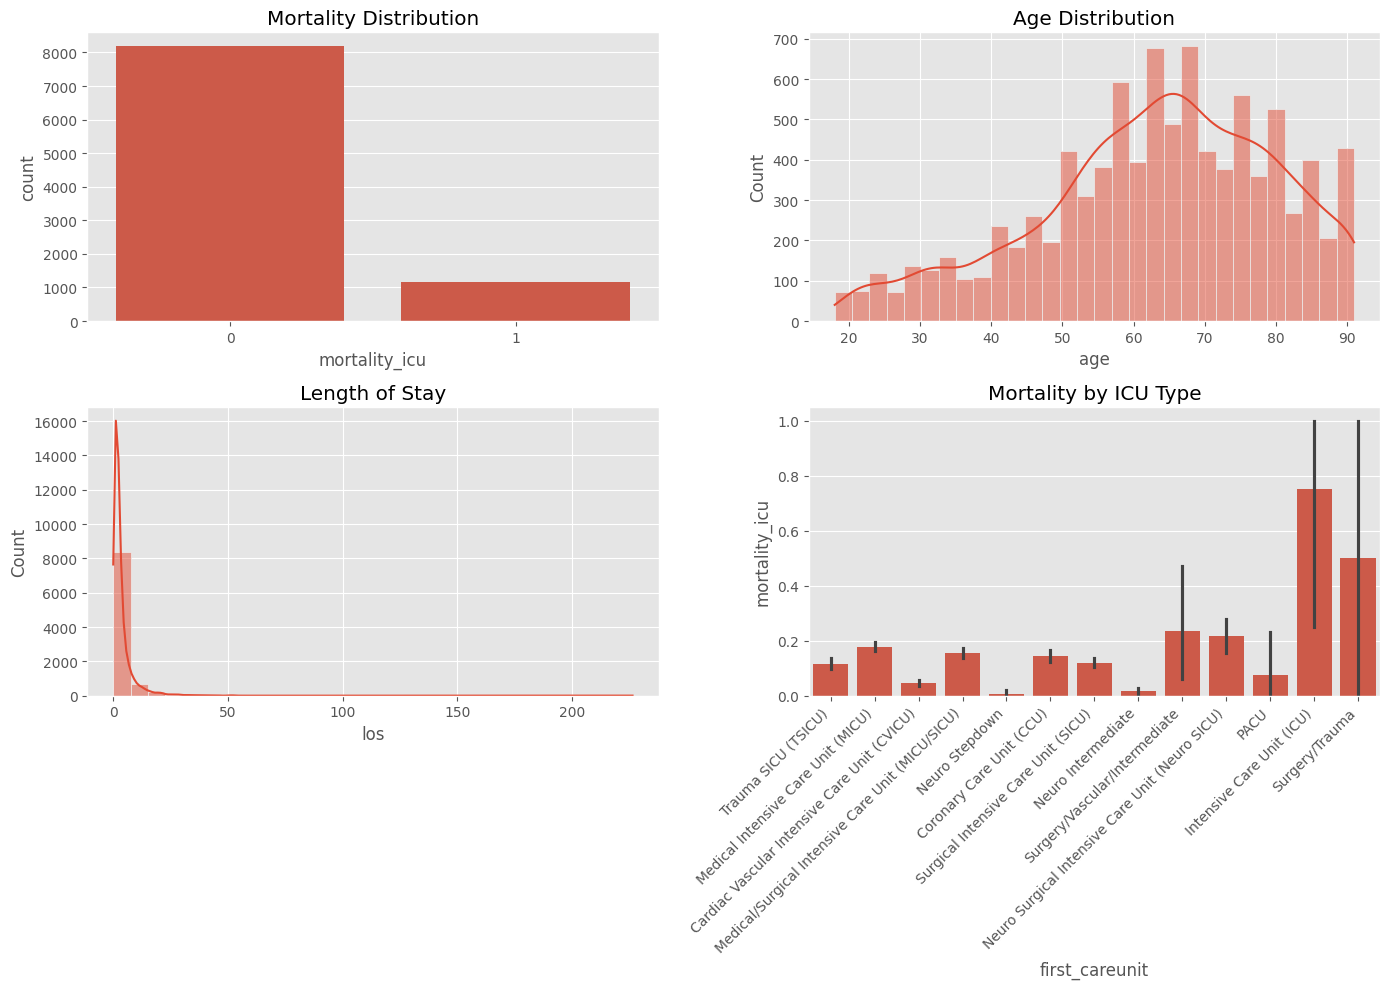

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

# Mortality rate
sns.countplot(x="mortality_icu", data=icu_df, ax=axes[0,0])
axes[0,0].set_title("Mortality Distribution")

# Age
sns.histplot(icu_df["age"], bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title("Age Distribution")

# LOS
sns.histplot(icu_df["los"], bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("Length of Stay")

# Mortality by ICU type
sns.barplot(x="first_careunit", y="mortality_icu", data=icu_df, ax=axes[1,1])
axes[1,1].set_title("Mortality by ICU Type")
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].set_xticklabels(
    axes[1,1].get_xticklabels(),
    ha='right'
)

plt.tight_layout()


Mortality Distribution:
The dataset is imbalanced, with significantly more survivors than deaths. This class imbalance must be considered during model evaluation.

Age Distribution:
Most ICU patients are between 55–75 years old. Older age groups are more represented, suggesting age may be an important predictor of mortality.

Length of Stay (LOS):
LOS is highly right-skewed, with most stays being short and a few extreme long outliers. Transformation may be required if used in modeling.

Mortality by ICU Type:
Mortality rates vary across ICU types, indicating differences in patient severity and case mix. ICU type may be a relevant predictive feature.

#### Vitals vs Mortality

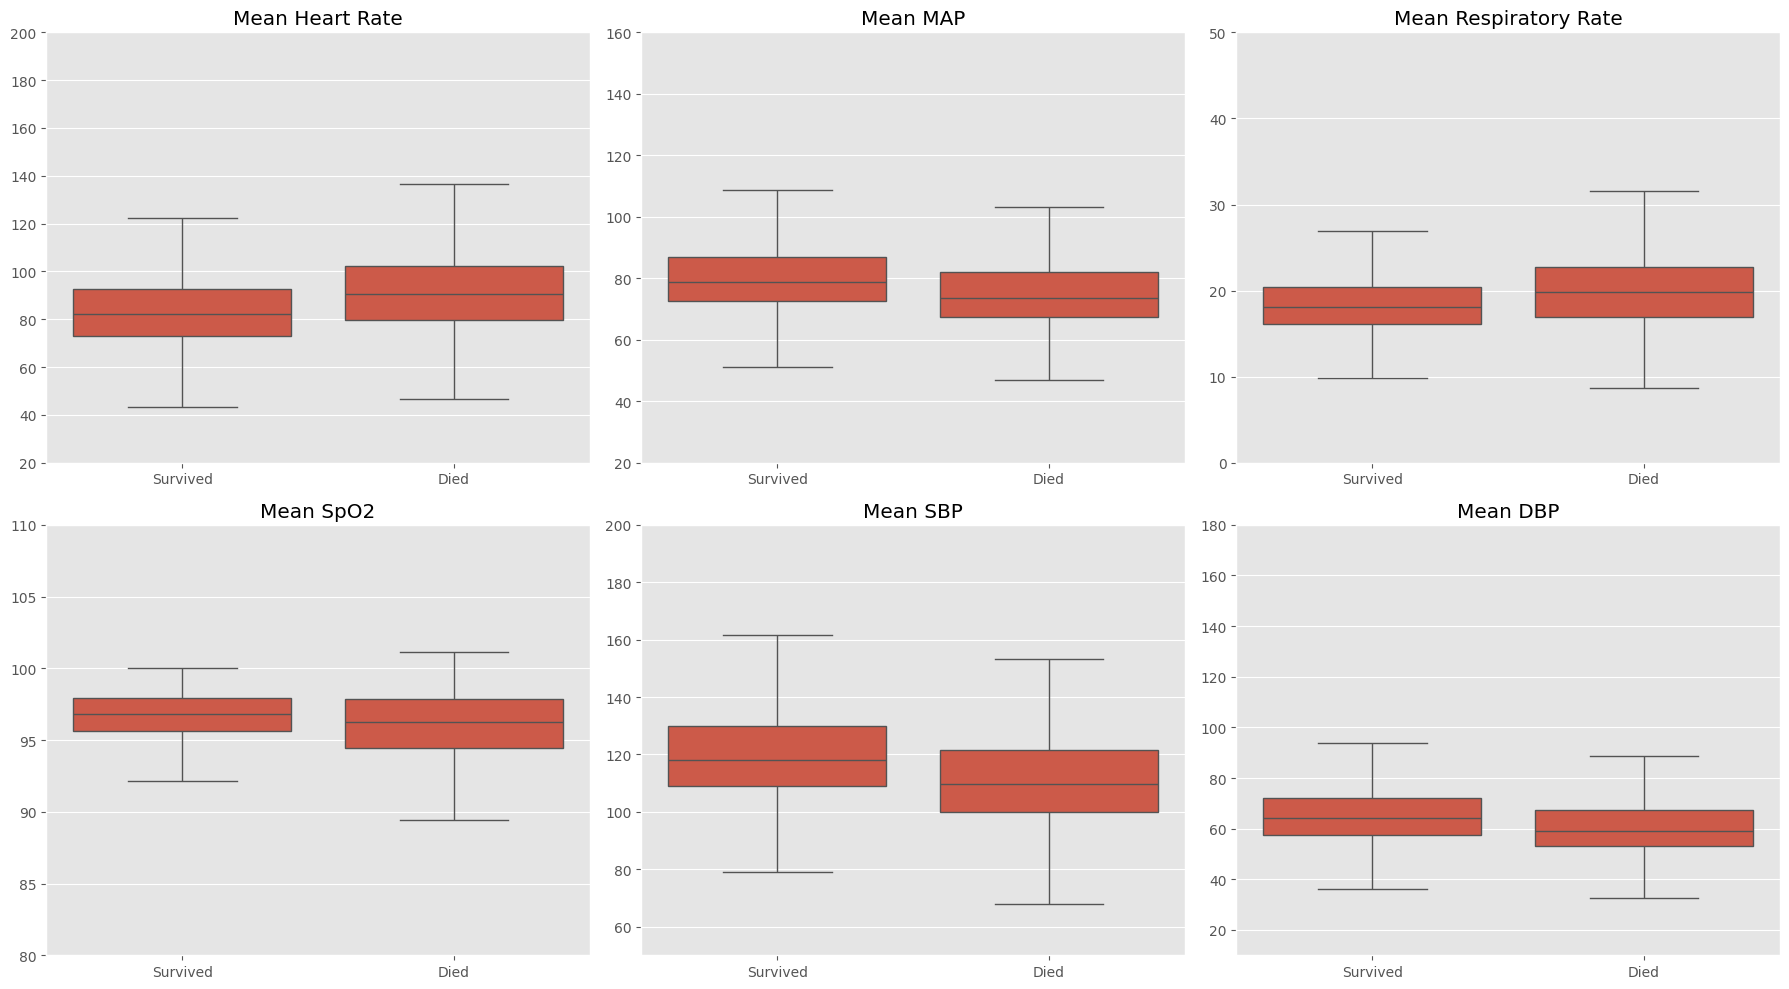

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18,10))

# Rename mortality labels for better visualization
icu_df["mortality_label"] = icu_df["mortality_icu"].map({0: "Survived", 1: "Died"})

# HR
sns.boxplot(x="mortality_label", y="mean_hr", data=icu_df,
            showfliers=False, ax=axes[0,0])
axes[0,0].set_title("Mean Heart Rate")
axes[0,0].set_ylim(20, 200)

# MAP
sns.boxplot(x="mortality_label", y="mean_map", data=icu_df,
            showfliers=False, ax=axes[0,1])
axes[0,1].set_title("Mean MAP")
axes[0,1].set_ylim(20, 160)

# RR
sns.boxplot(x="mortality_label", y="mean_rr", data=icu_df,
            showfliers=False, ax=axes[0,2])
axes[0,2].set_title("Mean Respiratory Rate")
axes[0,2].set_ylim(0, 50)

# SpO2
sns.boxplot(x="mortality_label", y="mean_spo2", data=icu_df,
            showfliers=False, ax=axes[1,0])
axes[1,0].set_title("Mean SpO2")
axes[1,0].set_ylim(80, 110)

# SBP
sns.boxplot(x="mortality_label", y="mean_sbp", data=icu_df,
            showfliers=False, ax=axes[1,1])
axes[1,1].set_title("Mean SBP")
axes[1,1].set_ylim(50, 200)

# DBP
sns.boxplot(x="mortality_label", y="mean_dbp", data=icu_df,
            showfliers=False, ax=axes[1,2])
axes[1,2].set_title("Mean DBP")
axes[1,2].set_ylim(10, 180)

for ax in axes.flatten():
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


Heart Rate & Respiratory Rate: Higher in patients who died, indicating increased physiological stress.

MAP, SBP, DBP: Lower in non-survivors, suggesting hypotension is associated with mortality.

SpO₂: Slightly lower in patients who died, though differences are modest.

#### Labs vs Mortality

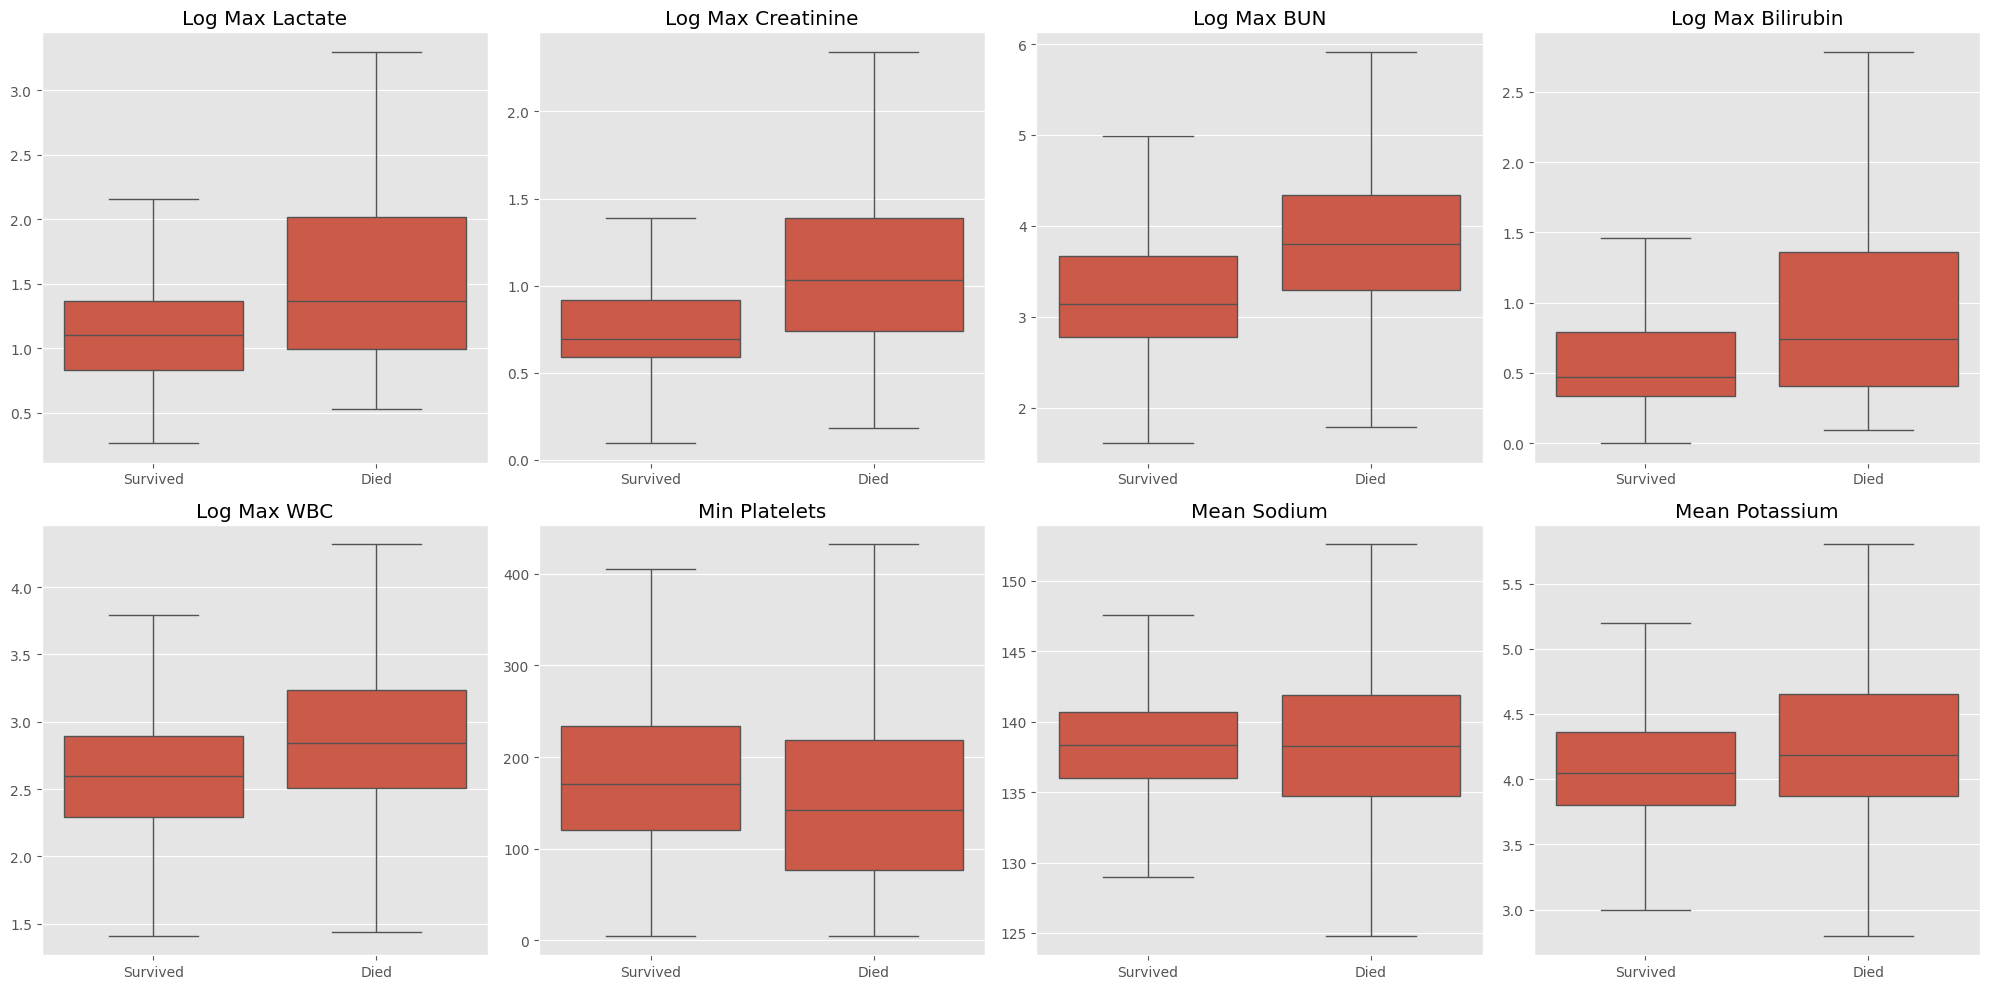

In [58]:
import numpy as np

fig, axes = plt.subplots(2, 4, figsize=(20,10))

icu_df["mortality_label"] = icu_df["mortality_icu"].map({0:"Survived", 1:"Died"})

plots = [
    "max_lactate",
    "max_creatinine",
    "max_bun",
    "max_bilirubin",
    "max_wbc",
    "min_platelets",
    "mean_sodium",
    "mean_potassium"
]

titles = [
    "Log Max Lactate",
    "Log Max Creatinine",
    "Log Max BUN",
    "Log Max Bilirubin",
    "Log Max WBC",
    "Min Platelets",
    "Mean Sodium",
    "Mean Potassium"
]

for ax, col, title in zip(axes.flatten(), plots, titles):

    # Apply log1p only to skewed variables
    if col in ["max_lactate", "max_creatinine", "max_bun",
               "max_bilirubin", "max_wbc"]:
        y_vals = np.log1p(icu_df[col])
    else:
        y_vals = icu_df[col]

    sns.boxplot(
        x=icu_df["mortality_label"],
        y=y_vals,
        showfliers=False,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


Lactate, Creatinine, BUN, Bilirubin: Higher in non-survivors, indicating worse organ dysfunction (renal, hepatic, and tissue perfusion).

WBC: Elevated in patients who died, suggesting stronger inflammatory response.

Platelets: Lower in non-survivors, consistent with possible coagulopathy or severe illness.

Sodium & Potassium: Slightly more variable in non-survivors, though differences are less pronounced.

Overall, non-survivors show biochemical evidence of multi-organ dysfunction within the first 72 hours.

In [21]:
icu_df.describe().T


,count,mean,std,min,25%,50%,75%,max
stay_id,9351.0,3.502870e+07,2.890243e+06,3.000166e+07,3.251606e+07,3.504282e+07,3.752343e+07,3.999986e+07
age,9351.0,6.299187e+01,1.691191e+01,1.800000e+01,5.300000e+01,6.500000e+01,7.600000e+01,9.100000e+01
mortality_icu,9351.0,1.240509e-01,3.296572e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
los,9350.0,3.619735e+00,5.605463e+00,1.446759e-03,1.102624e+00,1.990469e+00,3.839899e+00,2.264031e+02
max_hr,9340.0,1.079621e+02,2.567125e+01,0.000000e+00,9.200000e+01,1.050000e+02,1.210000e+02,1.002000e+03
min_hr,9340.0,6.659165e+01,1.634402e+01,0.000000e+00,5.800000e+01,6.600000e+01,7.600000e+01,1.490000e+02
mean_hr,9340.0,8.436738e+01,1.495602e+01,0.000000e+00,7.361266e+01,8.314460e+01,9.396051e+01,1.544714e+02
max_sbp,9314.0,1.553056e+02,1.843104e+02,3.800000e+01,1.360000e+02,1.510000e+02,1.670000e+02,1.297400e+04
min_sbp,9314.0,8.943143e+01,1.804730e+01,-6.000000e+00,8.000000e+01,8.900000e+01,1.000000e+02,1.700000e+02
mean_sbp,9314.0,1.193510e+02,1.682376e+01,3.800000e+01,1.079545e+02,1.171545e+02,1.292798e+02,5.353793e+02


## Missingness

In [22]:
missing_pct = (icu_df.isnull().mean() * 100).round(2)
missing_pct.sort_values(ascending=False)


max_pao2              57.32
max_fio2              51.24
max_bilirubin         47.18
min_bilirubin         47.18
mean_bilirubin        47.18
min_lactate           41.27
max_lactate           41.27
mean_lactate          41.27
total_urine_72h        3.49
mean_platelets         2.01
min_platelets          2.01
max_platelets          2.01
min_wbc                1.95
max_wbc                1.95
mean_wbc               1.95
max_hemog              1.94
mean_hemog             1.94
min_hemog              1.94
max_bun                1.91
min_bun                1.91
mean_bun               1.91
mean_creatinine        1.89
min_creatinine         1.89
max_creatinine         1.89
mean_sodium            1.81
max_sodium             1.81
min_sodium             1.81
min_potassium          1.78
max_potassium          1.78
mean_potassium         1.78
mean_temp_c            1.47
min_sbp                0.40
mean_sbp               0.40
min_dbp                0.40
mean_dbp               0.40
max_dbp             

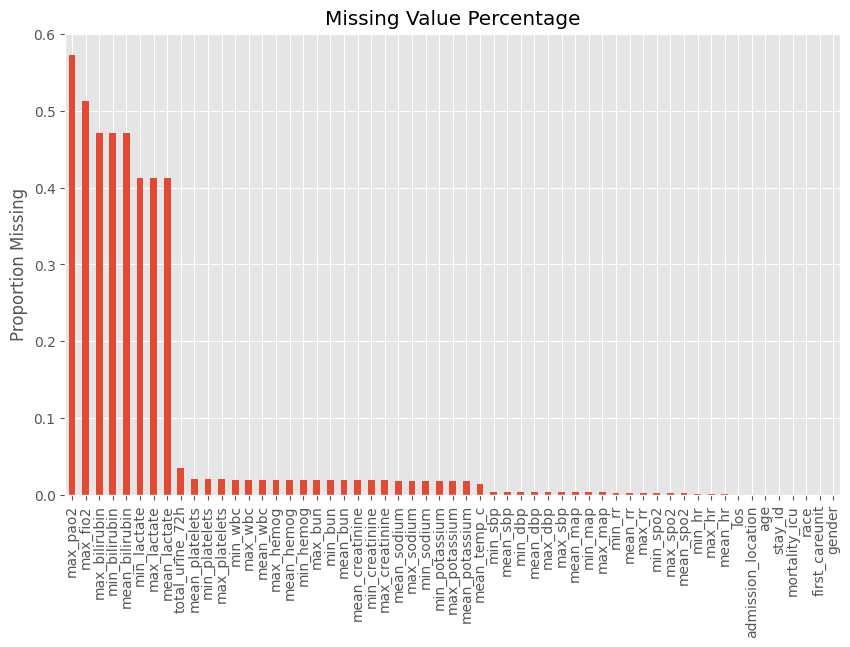

In [23]:
missing = icu_df.isnull().mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
missing.plot(kind="bar")
plt.title("Missing Value Percentage")
plt.ylabel("Proportion Missing")
plt.show()

High Missingness (>40–50%): PaO₂, FiO₂, bilirubin, and lactate show substantial missing values, likely because these tests are ordered selectively for sicker patients.

Moderate Missingness (~3–5%): Urine output and some lab aggregates have limited missing data.

Low Missingness (<2%): Most vitals (HR, BP, RR, SpO₂) and common labs (sodium, potassium, creatinine, BUN, WBC, hemoglobin) are largely complete.

No Missingness: Demographics and outcome variables (age, gender, mortality, ICU type) are fully available.

Overall, missingness is concentrated in specific laboratory variables rather than core vital signs, which will require careful handling during modeling.

In [61]:
# Select only numeric columns
num_df = icu_df.select_dtypes(include=np.number).drop(columns=["stay_id"])

corr_matrix = num_df.corr().abs()
threshold = 0.85

# Upper triangle of matrix (avoid duplicates)
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Find features with correlation above threshold
high_corr_pairs = [
    (column, row)
    for column in upper.columns
    for row in upper.index
    if upper.loc[row, column] > threshold
]

high_corr_pairs

[('mean_dbp', 'max_dbp'),
 ('mean_map', 'max_map'),
 ('mean_spo2', 'max_spo2'),
 ('min_creatinine', 'max_creatinine'),
 ('mean_creatinine', 'max_creatinine'),
 ('mean_creatinine', 'min_creatinine'),
 ('mean_lactate', 'max_lactate'),
 ('mean_lactate', 'min_lactate'),
 ('min_bilirubin', 'max_bilirubin'),
 ('mean_bilirubin', 'max_bilirubin'),
 ('mean_bilirubin', 'min_bilirubin'),
 ('mean_hemog', 'max_hemog'),
 ('mean_hemog', 'min_hemog'),
 ('mean_sodium', 'max_sodium'),
 ('mean_sodium', 'min_sodium'),
 ('mean_bun', 'max_bun'),
 ('min_platelets', 'max_platelets'),
 ('mean_platelets', 'max_platelets'),
 ('mean_platelets', 'min_platelets')]

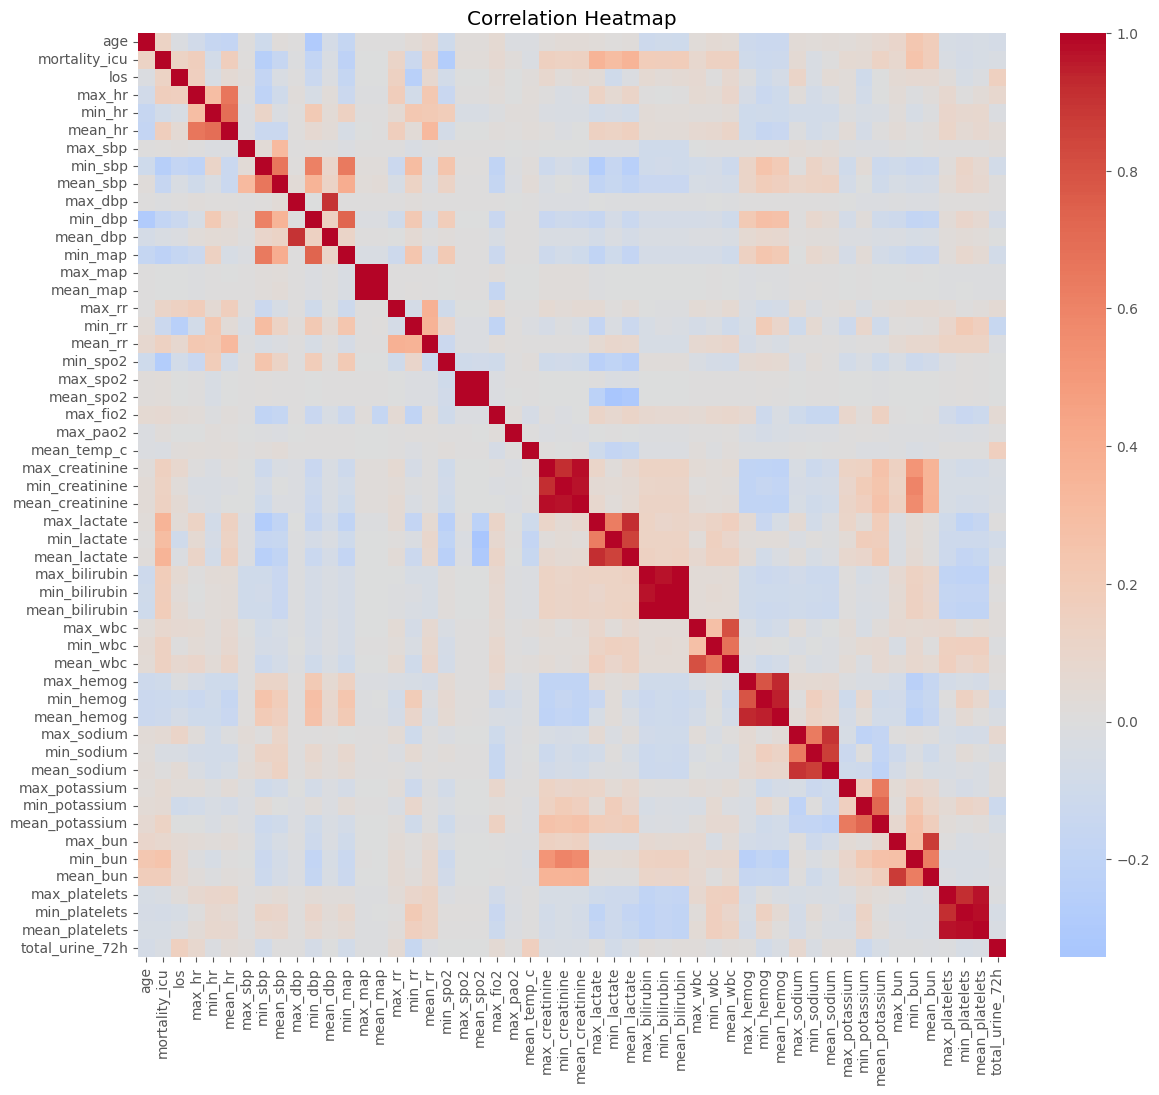

In [62]:
plt.figure(figsize=(14,12))
sns.heatmap(num_df.corr(),cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

Several features derived from the same physiological variable (mean, min, max) showed high correlation. To reduce multicollinearity and improve model stability, only one representative statistic per variable will be retained for modeling.

Detailed analysis is documented under Diary/DataExploartion.md